## Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy

## 1D Heat equation: $\frac{\partial u}{\partial t}-\alpha \frac{\partial^2 u}{\partial x^2}=0$, $\alpha = 0.1$

In [2]:
def heat_equation(u, TX, alpha_train):
    d1 = torch.autograd.grad(
        outputs = u,
        inputs = TX,
        grad_outputs = torch.ones_like(u),
        create_graph = True
    )[0]

    u_t = d1[:, 0:1]
    u_x = d1[:, 1:2]

    d2 = torch.autograd.grad(
        outputs = u_x,
        inputs = TX,
        grad_outputs = torch.ones_like(u_x),
        create_graph = True
    )[0]

    u_xx = d2[:, 1:2]

    return u_t - alpha_train * u_xx

Exact solution:

In [3]:
alpha_true = 0.1

def exact_solution(TX, alpha_true = 0.1):
    return torch.exp(-alpha_true *  np.pi**2 * TX[:, 0:1]) * torch.sin(np.pi * TX[:, 1:2])

Generate datasets:

In [4]:
torch.manual_seed(42)

n_data = 200
TX = torch.rand(n_data, 2, dtype=torch.float, requires_grad=True)

u_true = exact_solution(TX)

n_train = 2000
TX_collocation = torch.rand(n_train, 2, dtype=torch.float, requires_grad=True)

Define model:

In [5]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(2, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

Define loss function:

In [6]:
def loss_fcn(model, TX_collocation, TX, alpha_train, physics_weight, data_weight):
    model.train()

    u_pred1 = model(TX_collocation)
    residual = heat_equation(u_pred1, TX_collocation, alpha_train)
    physics_loss = torch.mean(residual**2)

    u_pred2 = model(TX)
    data_loss = torch.mean((u_pred2 - u_true)**2)

    weighted_total_loss = physics_loss * physics_weight + data_loss * data_weight

    return physics_loss, data_loss, weighted_total_loss


Training setup

In [ ]:
alpha_train = nn.Parameter(torch.tensor([1.0], dtype=torch.float))

stages = [
    {
        'optimizer':torch.optim.Adam(list(model.parameters()), lr=1e-3),
        'physics_weight':0.0,
        'data_weight':1.0,
        'target':0.1**2
    },
    {
        'optimizer':torch.optim.Adam([
            {"params": model.parameters(), "lr": 1e-4},
            {"params": [alpha_train], "lr": 1e-3},
        ]),
        'physics_weight':1.0,
        'data_weight':100.0,
        'target':0.08**2
    },
    {
        'optimizer':torch.optim.Adam([
            {"params": model.parameters(), "lr": 1e-4},
            {"params": [alpha_train], "lr": 5e-4},
        ]),
        'physics_weight':1.0,
        'data_weight':10.0,
        'target':0.05**2
    },
    {
        'optimizer':torch.optim.Adam([
            {"params": model.parameters(), "lr": 1e-5},
            {"params": [alpha_train], "lr": 1e-4},
        ]),
        'physics_weight':1.0,
        'data_weight':1.0,
        'target':0.01**2
    }
]

physics_loss_list = []
data_loss_list = []
weighted_total_loss_list = []
total_loss_list = []
alpha_list = []

In [ ]:
start_epoch = 0
n_epochs = 10000
patience = 200


Set up training cycle:

In [7]:
alpha_train = nn.Parameter(torch.tensor([1.0], dtype=torch.float))
pretrained_optimizer = torch.optim.Adam(list(model.parameters()), lr=1e-3)
refined_optimizer = torch.optim.Adam(list(model.parameters()) + [alpha_train], lr=1e-5)

physics_loss_list = []
data_loss_list = []
total_loss_list = []
alpha_list = []

Training model:

In [8]:
start_epoch = 0
n_epochs = 2000
patience = 200

optimizer = pretrained_optimizer

best_epoch = start_epoch

for i in range(start_epoch, start_epoch+n_epochs):
    # physics_weight = torch.tensor([0], dtype=torch.float, requires_grad=True)
    # data_weight = torch.tensor([1], dtype=torch.float, requires_grad=True)
    physics_weight = 0.0
    data_weight = 1.0
    physics_loss, data_loss, weighted_total_loss = loss_fcn(model, TX_collocation, TX, alpha_train, physics_weight, data_weight)
    optimizer.zero_grad()
    weighted_total_loss.backward(retain_graph=True)
    optimizer.step()

    physics_loss_list.append(physics_loss.item())
    data_loss_list.append(data_loss.item())
    total_loss_list.append(weighted_total_loss.item())
    alpha_list.append(alpha_train.item())

    if i % 100 == 0:
        print(f'epoch:', i)

    if weighted_total_loss < total_loss_list[best_epoch]:
        best_epoch = i
        best_model = copy.deepcopy(model)
    elif best_epoch <= i - patience:
        print('Training finished early')
        break

print('Need more training')

epoch: 0
epoch: 100
epoch: 200
epoch: 300
epoch: 400
epoch: 500
epoch: 600
epoch: 700
epoch: 800
epoch: 900
epoch: 1000
epoch: 1100
epoch: 1200
epoch: 1300
epoch: 1400
epoch: 1500
epoch: 1600
epoch: 1700
epoch: 1800
epoch: 1900
Need more training


Plot losses

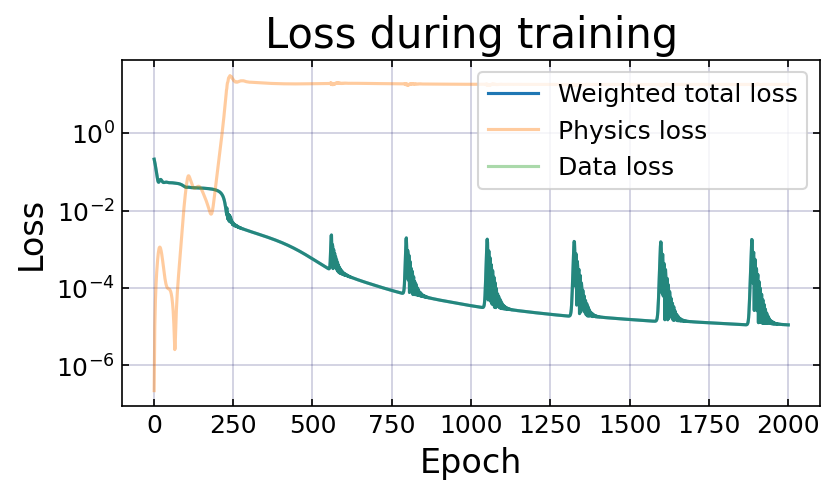

In [9]:
epochs = np.linspace(1, len(total_loss_list), len(total_loss_list))

fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(epochs, total_loss_list, label='Weighted total loss')
ax.plot(epochs, physics_loss_list, label='Physics loss', alpha=0.4)
ax.plot(epochs, data_loss_list, label='Data loss', alpha = 0.4)
ax.set_xlabel('Epoch',fontsize = 16)
ax.set_ylabel('Loss',fontsize = 16)
ax.set_yscale('log')
ax.set_title('Loss during training',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()

Plot evolution of $\alpha$

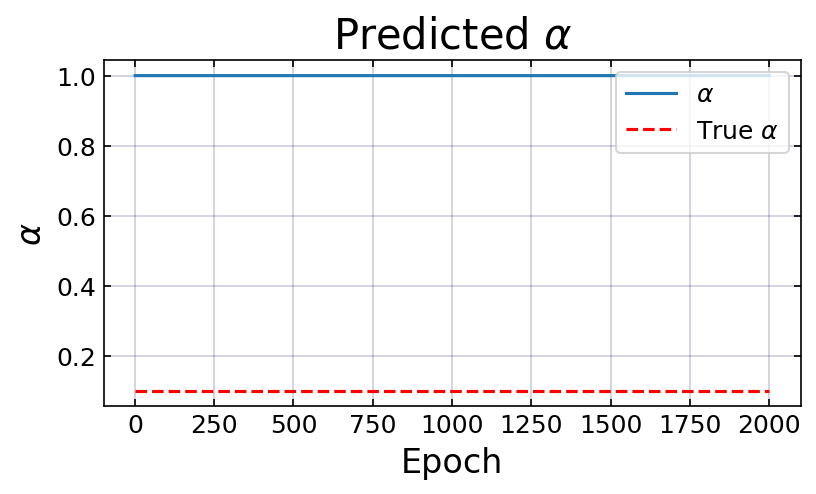

In [10]:
fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(epochs, alpha_list, label='$\\alpha$')
ax.hlines(0.1, 1, epochs[-1], linestyles='--', colors='red', label='True $\\alpha$')
ax.set_xlabel('Epoch',fontsize = 16)
ax.set_ylabel('$\\alpha$',fontsize = 16) 
ax.set_title('Predicted $\\alpha$',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()

Compare with exact solution

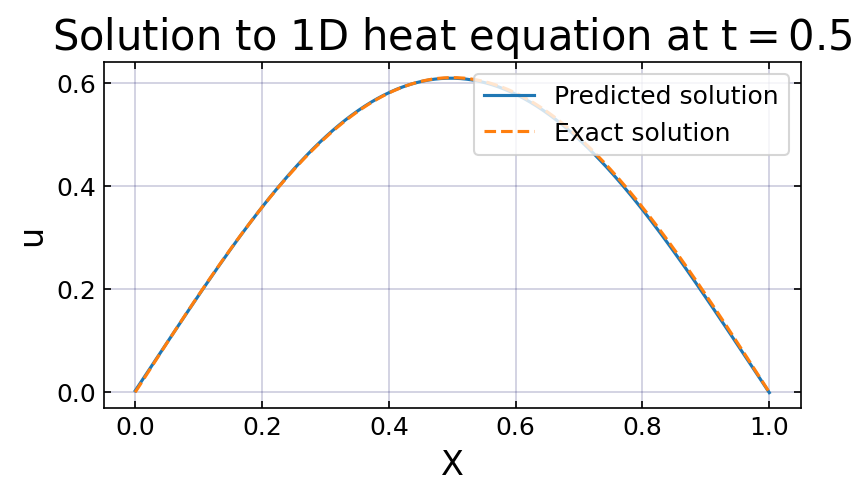

In [11]:
X_test = torch.linspace(0, 1, 200).reshape(-1, 1)
T_test = torch.ones_like(X_test) * 0.5
TX_test = torch.cat([T_test, X_test], dim=1)

u_exact = exact_solution(TX_test).detach()

best_model.eval()
with torch.no_grad():
    u_pred = best_model(TX_test).detach()

fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(X_test, u_pred, label='Predicted solution')
ax.plot(X_test, u_exact, label='Exact solution', linestyle='--')
ax.set_xlabel('X',fontsize = 16)
ax.set_ylabel('u',fontsize = 16)
ax.set_title('Solution to 1D heat equation at t$=0.5$',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()

In [ ]:
print(alpha_list[best_epoch])
print(total_loss_list[best_epoch])
print(abs(alpha_list[best_epoch] - alpha_true) / alpha_true * 100)

### Noisy data

Generate noisy data

In [ ]:
noise_level = 0.01

scale = np.std(u_true.detach().numpy().flatten()) * noise_level
rng = np.random.default_rng(seed=42)
noise = rng.normal(loc=0, scale=scale, size=n_data).reshape(-1, 1)
u_true_noise = u_true.detach().numpy() + noise
u_true_noise = torch.tensor(u_true_noise, dtype=torch.float, requires_grad=True)

Define model:

In [ ]:
noisy_model = nn.Sequential(
    nn.Linear(2, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 1)
)

Set up training cycle:

In [ ]:
alpha_train_noise = nn.Parameter(torch.tensor([1.0], dtype=torch.float))
optimizer_noise = torch.optim.Adam(list(noisy_model.parameters()) + [alpha_train_noise], lr=1e-5)

physics_loss_list_noise = []
data_loss_list_noise = []
total_loss_list_noise = []
alpha_list_noise = []

Training model:

In [ ]:
start_epoch_noise = 0
n_epochs_noise = 5000
patience_noise = 500

best_epoch_noise = start_epoch_noise

for i in range(start_epoch_noise, start_epoch_noise+n_epochs_noise):
    physics_loss_noise, data_loss_noise, total_loss_noise = loss_fcn(noisy_model, TX_collocation, TX, alpha_train_noise)
    optimizer_noise.zero_grad()
    total_loss_noise.backward(retain_graph=True)
    optimizer_noise.step()

    physics_loss_list_noise.append(physics_loss_noise.item())
    data_loss_list_noise.append(data_loss_noise.item())
    total_loss_list_noise.append(total_loss_noise.item())
    alpha_list_noise.append(alpha_train_noise.item())

    if i % 100 == 0:
        print(f'epoch:', i)

    if total_loss_noise < total_loss_list_noise[best_epoch_noise]:
        best_epoch_noise = i
        best_noisy_model = copy.deepcopy(noisy_model)
    elif best_epoch_noise <= i - patience_noise:
        print('Copy finished early')
        break

print('Need more training')

Plot losses

In [ ]:
epochs_noise = np.linspace(1, len(total_loss_list_noise), len(total_loss_list_noise))

fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(epochs_noise, total_loss_list_noise, label='Total loss')
ax.plot(epochs_noise, physics_loss_list_noise, label='Physics loss', alpha=0.4)
ax.plot(epochs_noise, data_loss_list_noise, label='Data loss', alpha=0.4)
ax.set_xlabel('Epoch',fontsize = 16)
ax.set_ylabel('Loss',fontsize = 16)
ax.set_yscale('log')
ax.set_title('Loss during training',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()

Plot evolution of $\alpha$

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(epochs_noise, alpha_list_noise, label='$\\alpha$')
ax.hlines(0.1, 1, epochs_noise[-1], linestyles='--', colors='red', label='True $\\alpha$')
ax.set_xlabel('Epoch',fontsize = 16)
ax.set_ylabel('$\\alpha$',fontsize = 16) 
ax.set_title('Predicted $\\alpha$',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()

Compare with exact solution

In [ ]:
X_test_noise = torch.linspace(0, 1, 200).reshape(-1, 1)
T_test_noise = torch.ones_like(X_test_noise) * 0.5
TX_test_noise = torch.cat([T_test_noise, X_test_noise], dim=1)

u_exact_noise = exact_solution(TX_test_noise).detach()

best_noisy_model.eval()
with torch.no_grad():
    u_pred_noise = best_noisy_model(TX_test_noise).detach()

fig, ax = plt.subplots(1,1,figsize = (6,3),dpi = 150)
ax.plot(X_test_noise, u_pred_noise, label='Predicted solution')
ax.plot(X_test_noise, u_exact_noise, label='Exact solution', linestyle='--')
ax.set_xlabel('X',fontsize = 16)
ax.set_ylabel('u',fontsize = 16)
ax.set_title('Solution to 1D heat equation at t$=0.5$',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()

In [ ]:
print(alpha_list_noise[best_epoch_noise])
print(total_loss_list_noise[best_epoch_noise])
print(abs(alpha_list_noise[best_epoch_noise] - alpha_true) / alpha_true * 100)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import copy

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------
# Important:
# For data points, we do NOT need requires_grad=True.
# Gradients wrt inputs are only needed at collocation points for the PDE residual.

device = next(model.parameters()).device

XT_data = XT.detach().clone().to(device)
u_data = u_true.detach().clone().to(device)

XT_collocation_base = XT_collocation.detach().clone().to(device)


# ------------------------------------------------------------
# 2. Positive alpha parametrisation
# ------------------------------------------------------------
# Instead of training alpha directly, train raw_alpha and map it to a positive value.
#
# alpha = softplus(raw_alpha) = log(1 + exp(raw_alpha))
#
# This guarantees alpha > 0, which is physically sensible for diffusivity.
# If you want to start alpha near 1.0, set alpha_init = 1.0.
# If you have a rough prior that alpha is around 0.1, set alpha_init = 0.1.

def inverse_softplus(y):
    """
    Returns z such that softplus(z) ≈ y.
    Used only to initialise raw_alpha from a physical alpha guess.
    """
    y = torch.as_tensor(y, dtype=torch.float)
    return torch.log(torch.expm1(y))


alpha_init = 1.0

raw_alpha = nn.Parameter(
    inverse_softplus(torch.tensor([alpha_init], dtype=torch.float)).to(device)
)

def get_alpha():
    return torch.nn.functional.softplus(raw_alpha)


# ------------------------------------------------------------
# 3. Loss function
# ------------------------------------------------------------
# weighted_total_loss is used for backpropagation.
# unscaled_total_loss is used for monitoring and stage-transition logic.
#
# They are deliberately separated.
#
# Example:
#     weighted_total_loss = 100 * data_loss + physics_loss
#     unscaled_total_loss = data_loss + physics_loss
#
# This matters because the weighted loss changes meaning from stage to stage.

def compute_losses(model, XT_collocation_base, XT_data, u_data,
                   lambda_data, lambda_physics):
    model.train()

    # -------------------------
    # Data loss
    # -------------------------
    u_pred_data = model(XT_data)
    data_loss = torch.mean((u_pred_data - u_data)**2)

    # -------------------------
    # Physics loss
    # -------------------------
    # In the pure data-pretraining stage, lambda_physics = 0.
    # There is no need to compute expensive second derivatives in that stage.
    if lambda_physics == 0.0:
        physics_loss = torch.zeros((), dtype=torch.float, device=device)
    else:
        # Need a fresh tensor with requires_grad=True each time.
        XTc = XT_collocation_base.clone().detach().requires_grad_(True)

        u_pred_collocation = model(XTc)

        alpha = get_alpha()
        residual = heat_equation(u_pred_collocation, XTc, alpha)

        physics_loss = torch.mean(residual**2)

    # This is the loss used for optimization.
    weighted_total_loss = (
        lambda_data * data_loss
        + lambda_physics * physics_loss
    )

    # This is the unweighted, unscaled diagnostic loss.
    # It is used to decide whether training has stabilized.
    unscaled_total_loss = data_loss + physics_loss

    return physics_loss, data_loss, weighted_total_loss, unscaled_total_loss


# ------------------------------------------------------------
# 4. Stability helpers
# ------------------------------------------------------------
# For stages 2-4, you asked to move stage based on:
#     1. stability of alpha
#     2. stability of unscaled total loss
#
# A useful stability measure is the relative span over a recent window:
#
#     relative span = (max - min) / |mean|
#
# This is better than just comparing first and last values because it detects
# oscillations inside the window.

def relative_window_span(values, eps=1e-12):
    values = np.asarray(values, dtype=float)

    if len(values) == 0:
        return np.inf

    numerator = np.max(values) - np.min(values)
    denominator = np.abs(np.mean(values)) + eps

    return numerator / denominator


def make_adam_optimizer(stage):
    """
    Redefining the optimizer between stages is fine.
    In fact, it is often beneficial because Adam stores momentum/adaptive
    statistics, and each stage has a different objective landscape.
    """
    if stage["alpha_lr"] is None:
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=stage["model_lr"]
        )
    else:
        optimizer = torch.optim.Adam([
            {"params": model.parameters(), "lr": stage["model_lr"]},
            {"params": [raw_alpha], "lr": stage["alpha_lr"]},
        ])

    return optimizer


# ------------------------------------------------------------
# 5. Four-stage training configuration
# ------------------------------------------------------------
# Stage 1:
#   Data only.
#   The network must first learn u(t, x). Without a good learned u, the
#   derivatives u_t and u_xx are not meaningful, so alpha is not identifiable.
#
# Stages 2-4:
#   Gradually introduce physics.
#   Early inverse-PINN stages still protect the data fit strongly.
#   Later stages let the PDE residual matter more.
#
# max_stage_epochs is a fallback so training does not get stuck forever in
# one stage if the threshold is not met. Set it to None if you want strict
# threshold-only stage changes.

# A scale-aware default for the first threshold:
# If u_scale ~ 0.1 and you want about 5% RMSE, then
# MSE target = (0.05 * 0.1)^2 = 2.5e-5.
u_scale = torch.sqrt(torch.mean(u_data**2)).item()
stage1_loss_target = (0.05 * u_scale)**2

# If you want to use your proposed looser threshold, uncomment this:
# stage1_loss_target = 1e-3

stages = [
    {
        "name": "Stage 1: data pretraining",
        "lambda_data": 1.0,
        "lambda_physics": 0.0,
        "model_lr": 1e-3,
        "alpha_lr": None,

        # Stage 1 transition criterion:
        "loss_abs_target": stage1_loss_target,

        "min_stage_epochs": 500,
        "max_stage_epochs": 3000,
    },
    {
        "name": "Stage 2: data-dominant PINN",
        "lambda_data": 100.0,
        "lambda_physics": 1.0,
        "model_lr": 1e-4,
        "alpha_lr": 1e-3,

        # Stage 2 transition criterion:
        # alpha and unscaled loss must be stable over the window.
        "window": 500,
        "alpha_rel_span_tol": 5e-2,
        "loss_rel_span_tol": 5e-2,

        "min_stage_epochs": 1000,
        "max_stage_epochs": 2500,
    },
    {
        "name": "Stage 3: moderately balanced PINN",
        "lambda_data": 10.0,
        "lambda_physics": 1.0,
        "model_lr": 5e-5,
        "alpha_lr": 5e-4,

        "window": 500,
        "alpha_rel_span_tol": 1e-2,
        "loss_rel_span_tol": 1e-2,

        "min_stage_epochs": 1000,
        "max_stage_epochs": 2500,
    },
    {
        "name": "Stage 4: balanced fine tuning",
        "lambda_data": 1.0,
        "lambda_physics": 1.0,
        "model_lr": 1e-5,
        "alpha_lr": 1e-4,

        "window": 500,
        "alpha_rel_span_tol": 5e-3,
        "loss_rel_span_tol": 5e-3,

        "min_stage_epochs": 1000,
        "max_stage_epochs": 2500,
    },
]


# ------------------------------------------------------------
# 6. Main Adam training loop
# ------------------------------------------------------------

n_adam_epochs = 10000

history = {
    "epoch": [],
    "stage_id": [],
    "stage_name": [],
    "physics_loss": [],
    "data_loss": [],
    "weighted_total_loss": [],
    "unscaled_total_loss": [],
    "alpha": [],
    "raw_alpha_grad": [],
}

stage_id = 0
stage_start_epoch = 0
optimizer = make_adam_optimizer(stages[stage_id])

best_unscaled_loss = np.inf
best_model_state = copy.deepcopy(model.state_dict())
best_raw_alpha = raw_alpha.detach().clone()

print(f"Starting {stages[stage_id]['name']}")

for epoch in range(n_adam_epochs):

    stage = stages[stage_id]
    stage_epoch = epoch - stage_start_epoch + 1

    physics_loss, data_loss, weighted_total_loss, unscaled_total_loss = compute_losses(
        model=model,
        XT_collocation_base=XT_collocation_base,
        XT_data=XT_data,
        u_data=u_data,
        lambda_data=stage["lambda_data"],
        lambda_physics=stage["lambda_physics"],
    )

    optimizer.zero_grad(set_to_none=True)
    weighted_total_loss.backward()

    # Store alpha gradient before optimizer.step().
    # In Stage 1, raw_alpha is not part of the loss, so grad is None.
    if raw_alpha.grad is None:
        raw_alpha_grad_value = np.nan
    else:
        raw_alpha_grad_value = raw_alpha.grad.detach().item()

    optimizer.step()

    alpha_value = get_alpha().detach().item()

    # Save history.
    history["epoch"].append(epoch)
    history["stage_id"].append(stage_id)
    history["stage_name"].append(stage["name"])
    history["physics_loss"].append(physics_loss.detach().item())
    history["data_loss"].append(data_loss.detach().item())
    history["weighted_total_loss"].append(weighted_total_loss.detach().item())
    history["unscaled_total_loss"].append(unscaled_total_loss.detach().item())
    history["alpha"].append(alpha_value)
    history["raw_alpha_grad"].append(raw_alpha_grad_value)

    # Save best model according to unscaled total loss.
    if unscaled_total_loss.detach().item() < best_unscaled_loss:
        best_unscaled_loss = unscaled_total_loss.detach().item()
        best_model_state = copy.deepcopy(model.state_dict())
        best_raw_alpha = raw_alpha.detach().clone()

    if epoch % 100 == 0:
        print(
            f"epoch {epoch:05d} | "
            f"{stage['name']} | "
            f"data = {data_loss.item():.3e} | "
            f"physics = {physics_loss.item():.3e} | "
            f"unscaled = {unscaled_total_loss.item():.3e} | "
            f"weighted = {weighted_total_loss.item():.3e} | "
            f"alpha = {alpha_value:.6f}"
        )

    # --------------------------------------------------------
    # Stage-transition logic
    # --------------------------------------------------------
    move_to_next_stage = False
    transition_reason = None

    # Do not move stages before the minimum stage length.
    if stage_epoch >= stage["min_stage_epochs"]:

        # -------------------------
        # Stage 1: data-only
        # -------------------------
        if stage["lambda_physics"] == 0.0:

            # Since physics weight is zero, unscaled total loss = data loss.
            if history["unscaled_total_loss"][-1] < stage["loss_abs_target"]:
                move_to_next_stage = True
                transition_reason = (
                    f"unscaled data loss below threshold "
                    f"{stage['loss_abs_target']:.3e}"
                )

        # -------------------------
        # Stages 2-4: inverse PINN
        # -------------------------
        else:
            window = stage["window"]

            if stage_epoch >= window:
                recent_alpha = history["alpha"][-window:]
                recent_unscaled_loss = history["unscaled_total_loss"][-window:]

                alpha_span = relative_window_span(recent_alpha)
                loss_span = relative_window_span(recent_unscaled_loss)

                alpha_stable = alpha_span < stage["alpha_rel_span_tol"]
                loss_stable = loss_span < stage["loss_rel_span_tol"]

                if alpha_stable and loss_stable:
                    move_to_next_stage = True
                    transition_reason = (
                        f"alpha stable, span = {alpha_span:.3e}; "
                        f"unscaled loss stable, span = {loss_span:.3e}"
                    )

        # Optional fallback: move on if this stage has consumed many epochs.
        if (
            not move_to_next_stage
            and stage["max_stage_epochs"] is not None
            and stage_epoch >= stage["max_stage_epochs"]
        ):
            move_to_next_stage = True
            transition_reason = (
                f"reached max_stage_epochs = {stage['max_stage_epochs']}"
            )

    # Actually change stage.
    if move_to_next_stage:

        print()
        print(f"Leaving {stage['name']} at epoch {epoch}.")
        print(f"Reason: {transition_reason}")
        print()

        if stage_id < len(stages) - 1:
            stage_id += 1
            stage_start_epoch = epoch + 1

            optimizer = make_adam_optimizer(stages[stage_id])

            print(f"Starting {stages[stage_id]['name']}")
            print()

        else:
            print("Final Adam stage has stabilized. Ending Adam training early.")
            break


# ------------------------------------------------------------
# 7. Optional: restore best Adam state before L-BFGS
# ------------------------------------------------------------
# This is often helpful if the last few Adam steps slightly worsened the
# unscaled loss.

model.load_state_dict(best_model_state)

with torch.no_grad():
    raw_alpha.copy_(best_raw_alpha)


# ------------------------------------------------------------
# 8. Final L-BFGS refinement
# ------------------------------------------------------------
# L-BFGS is often used after Adam in PINNs.
#
# Adam is good at getting into a reasonable region of parameter space.
# L-BFGS can then refine the solution using curvature information.
#
# Important:
# L-BFGS calls closure() multiple times per step.
# Do not append to history inside the closure unless you intentionally want
# many repeated entries.

lbfgs_lambda_data = 1.0
lbfgs_lambda_physics = 1.0

lbfgs_optimizer = torch.optim.LBFGS(
    list(model.parameters()) + [raw_alpha],
    lr=1.0,
    max_iter=500,
    max_eval=500,
    history_size=50,
    line_search_fn="strong_wolfe",
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
)

def lbfgs_closure():
    lbfgs_optimizer.zero_grad(set_to_none=True)

    physics_loss, data_loss, weighted_total_loss, unscaled_total_loss = compute_losses(
        model=model,
        XT_collocation_base=XT_collocation_base,
        XT_data=XT_data,
        u_data=u_data,
        lambda_data=lbfgs_lambda_data,
        lambda_physics=lbfgs_lambda_physics,
    )

    weighted_total_loss.backward()

    return weighted_total_loss


print()
print("Starting L-BFGS refinement...")
lbfgs_optimizer.step(lbfgs_closure)

# Evaluate final losses after L-BFGS.
physics_loss, data_loss, weighted_total_loss, unscaled_total_loss = compute_losses(
    model=model,
    XT_collocation_base=XT_collocation_base,
    XT_data=XT_data,
    u_data=u_data,
    lambda_data=lbfgs_lambda_data,
    lambda_physics=lbfgs_lambda_physics,
)

final_alpha = get_alpha().detach().item()

print()
print("Training complete.")
print(f"Final data loss:            {data_loss.item():.6e}")
print(f"Final physics loss:         {physics_loss.item():.6e}")
print(f"Final unscaled total loss:  {unscaled_total_loss.item():.6e}")
print(f"Final alpha:                {final_alpha:.8f}")